# Titanic Survival Prediction EDA

This notebook is the starting point for exploratory data analysis and feature engineering.

# Titanic Survival Prediction System

## Exploratory Data Analysis (EDA)

### Objectives

- Understand the dataset
- Explore the features
- Check missing values
- Analyze data distribution
- Study relationships between variables
- Prepare the dataset for preprocessing

## 1. Import Required Libraries

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In [2]:
# ==========================================
# Load Titanic Dataset
# ==========================================

df = pd.read_csv("../data/Titanic-Dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Dataset Overview

In [4]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 891
Number of Columns : 12


In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


## 4. Missing Value Analysis

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage.sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
dtype: float64

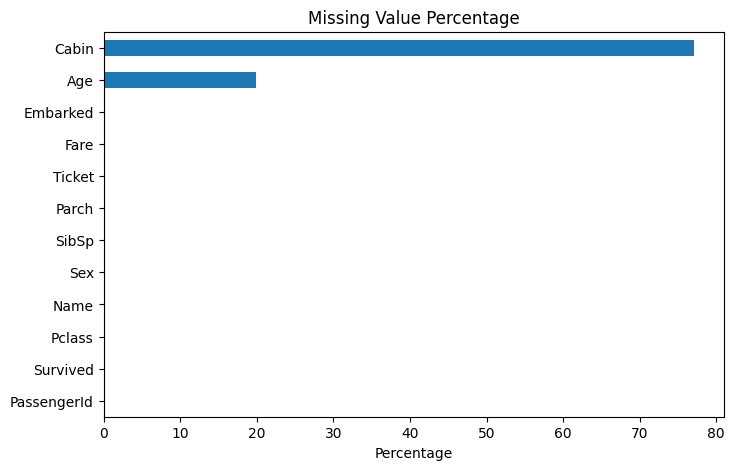

In [10]:
plt.figure(figsize=(8,5))

missing_percentage.sort_values().plot(kind="barh")

plt.title("Missing Value Percentage")
plt.xlabel("Percentage")

plt.show()

## 5. Duplicate Records

In [11]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


## 6. Data Types

In [12]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [13]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Columns")
print(numerical_columns)

print()

print("Categorical Columns")
print(categorical_columns)

Numerical Columns
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Columns
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


## 7. Univariate Analysis

Univariate analysis helps us understand the distribution of individual features.

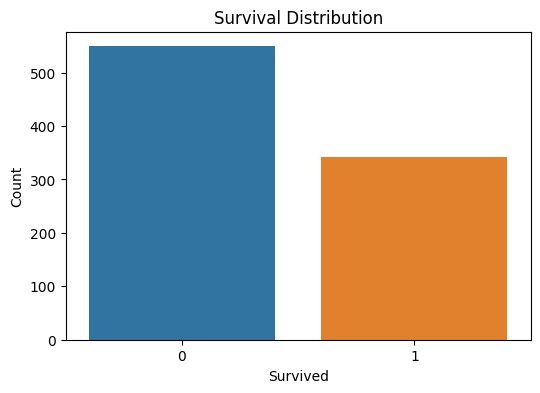

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

### Observation

- More passengers did not survive than survived.
- The dataset is slightly imbalanced.

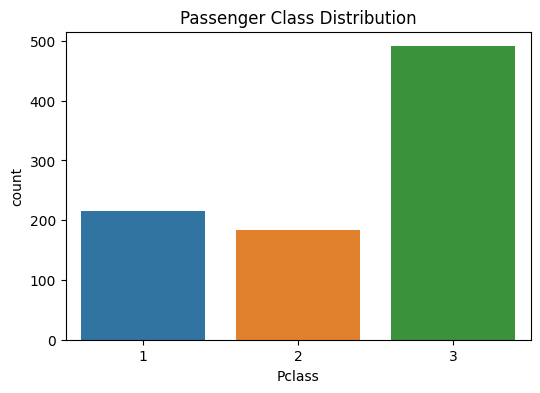

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pclass")

plt.title("Passenger Class Distribution")

plt.show()

### Observation

- Most passengers belonged to 3rd class.

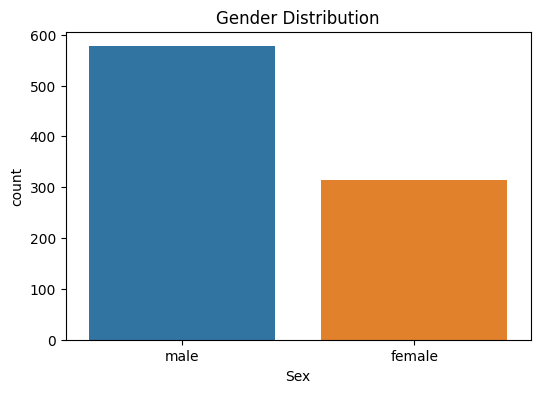

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sex")

plt.title("Gender Distribution")

plt.show()

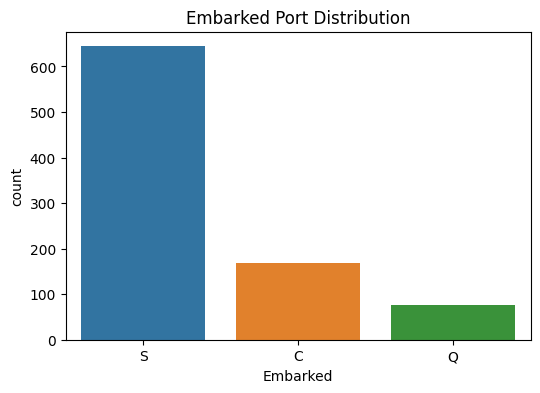

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Embarked")

plt.title("Embarked Port Distribution")

plt.show()

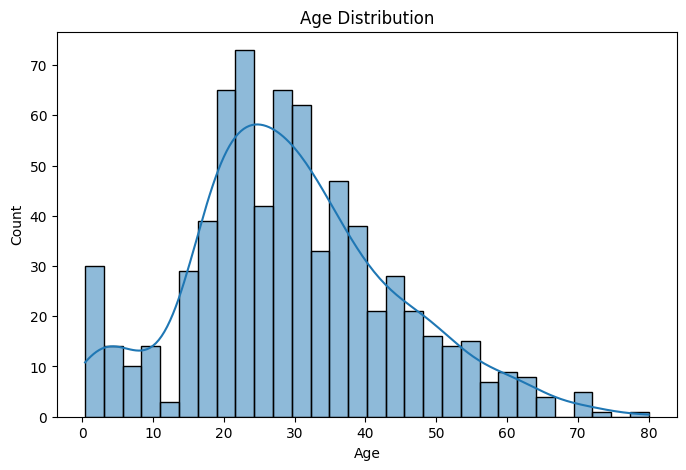

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

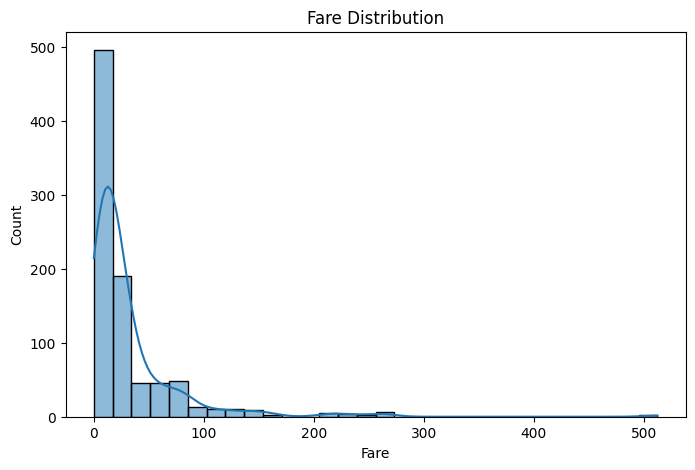

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Fare Distribution")

plt.show()

## 8. Bivariate Analysis

Bivariate analysis helps understand the relationship between two variables.

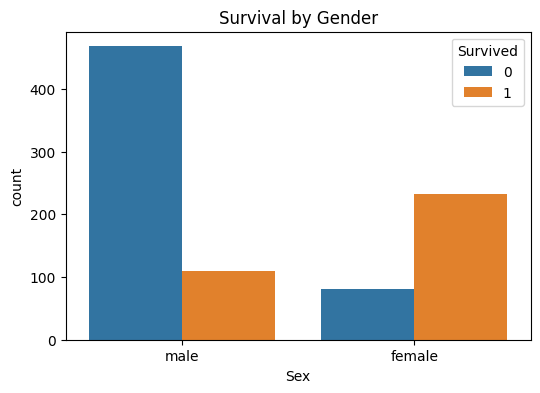

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")

plt.show()

### Observation

- Female passengers had a much higher survival rate.

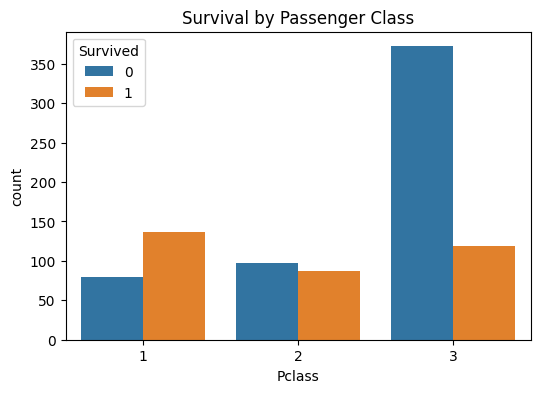

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")

plt.show()

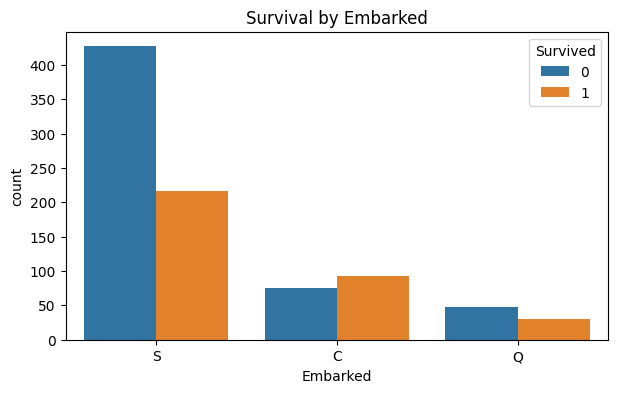

In [22]:
plt.figure(figsize=(7,4))

sns.countplot(data=df, x="Embarked", hue="Survived")

plt.title("Survival by Embarked")

plt.show()

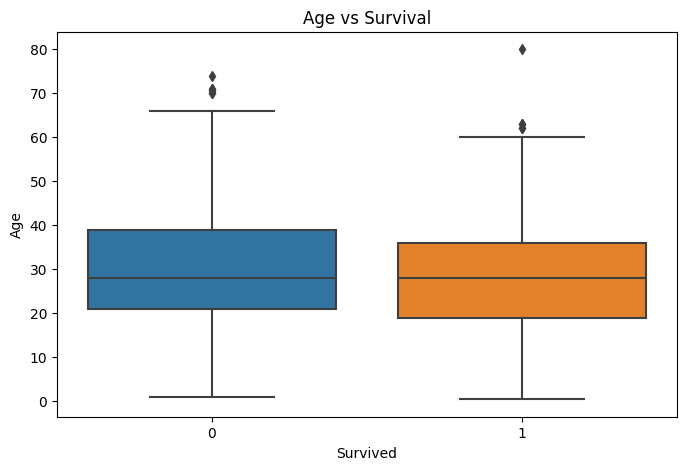

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Survived", y="Age")

plt.title("Age vs Survival")

plt.show()

## 9. Correlation Analysis

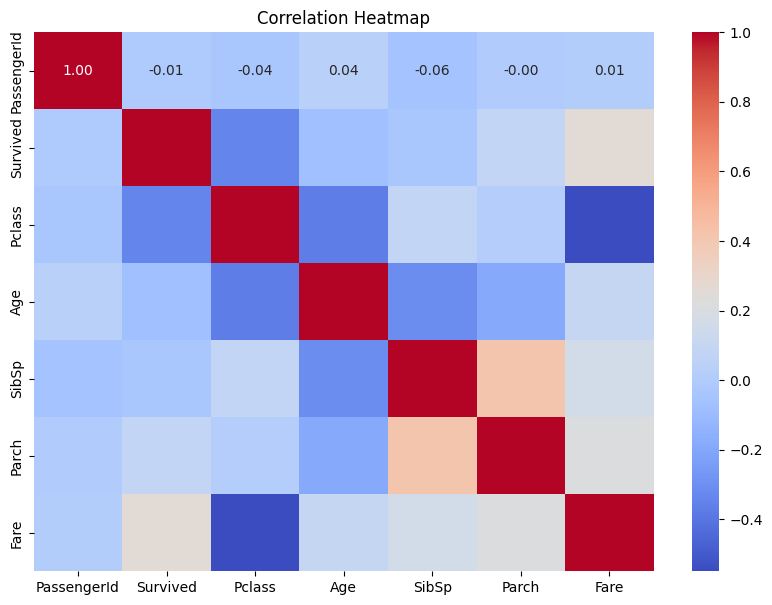

In [24]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## 10. Outlier Detection

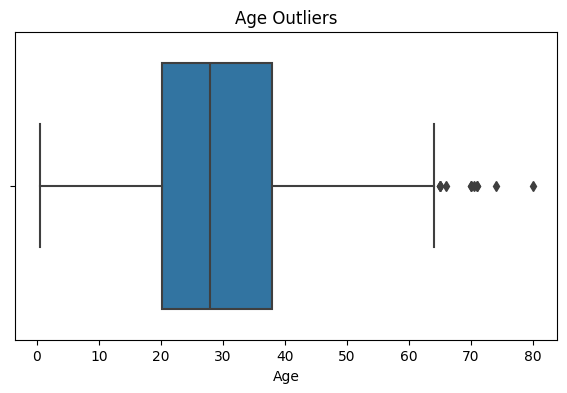

In [25]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df["Age"])

plt.title("Age Outliers")

plt.show()

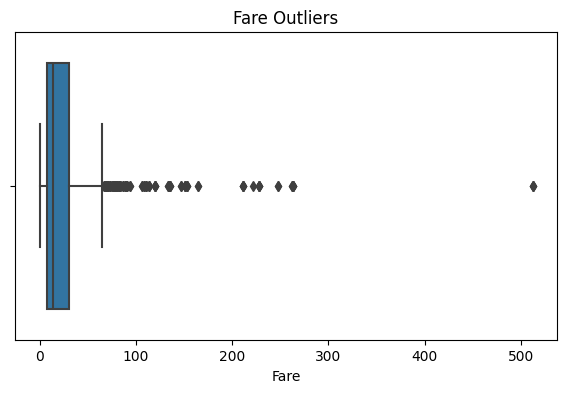

In [26]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df["Fare"])

plt.title("Fare Outliers")

plt.show()

# EDA Summary

### Key Findings

- Dataset contains missing values in Age, Cabin, and Embarked.
- Cabin has a large number of missing values.
- Female passengers had a higher survival rate.
- Passengers in 1st class survived more often.
- Fare contains several outliers.
- Age is approximately normally distributed.
- Dataset is suitable for preprocessing and model building.